In [47]:
import pandas as pd
import numpy as np
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold


In [2]:
data = pd.read_csv('cirrhosis.csv')
data.head(5)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [6]:
data.isnull().sum()

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [8]:
data['Drug'].value_counts(dropna=False)

Drug
D-penicillamine    158
Placebo            154
NaN                106
Name: count, dtype: int64

In [10]:
# Buat flag: apakah pasien ikut randomized trial atau tidak
data['in_trial'] = data['Drug'].notna()

In [11]:
# Cek: apakah missingness di kolom lain 100% overlap dengan flag ini?
for col in ['Ascites','Hepatomegaly','Spiders','Alk_Phos','SGOT','Cholesterol','Copper','Tryglicerides']:
    print(col, '-> missing hanya di luar trial?', (data[col].isna() == ~data['in_trial']).all() or data[col].isna().sum() == 0)

Ascites -> missing hanya di luar trial? True
Hepatomegaly -> missing hanya di luar trial? True
Spiders -> missing hanya di luar trial? True
Alk_Phos -> missing hanya di luar trial? True
SGOT -> missing hanya di luar trial? True
Cholesterol -> missing hanya di luar trial? False
Copper -> missing hanya di luar trial? False
Tryglicerides -> missing hanya di luar trial? False


In [12]:
for col in ['Cholesterol','Copper','Tryglicerides']:
    missing_in_trial = data[data['in_trial']][col].isna().sum()
    missing_out_trial = data[~data['in_trial']][col].isna().sum()
    print(f"{col}: missing di DALAM trial = {missing_in_trial}, missing di LUAR trial = {missing_out_trial}")

Cholesterol: missing di DALAM trial = 28, missing di LUAR trial = 106
Copper: missing di DALAM trial = 2, missing di LUAR trial = 106
Tryglicerides: missing di DALAM trial = 30, missing di LUAR trial = 106


In [14]:
print(data['Status'].value_counts())
print(data['Stage'].value_counts())

Status
C     232
D     161
CL     25
Name: count, dtype: int64
Stage
3.0    155
4.0    144
2.0     92
1.0     21
Name: count, dtype: int64


In [15]:
data['target'] = (data['Status'] == 'D').astype(int)
print(data['target'].value_counts())
print(data['target'].value_counts(normalize=True))

target
0    257
1    161
Name: count, dtype: int64
target
0    0.614833
1    0.385167
Name: proportion, dtype: float64


In [16]:
print(data.select_dtypes(include='object').columns.tolist())
for col in data.select_dtypes(include='object').columns:
    print(col, '->', data[col].unique())

['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
Status -> ['D' 'C' 'CL']
Drug -> ['D-penicillamine' 'Placebo' nan]
Sex -> ['F' 'M']
Ascites -> ['Y' 'N' nan]
Hepatomegaly -> ['Y' 'N' nan]
Spiders -> ['Y' 'N' nan]
Edema -> ['Y' 'N' 'S']


In [17]:
data.groupby('target')['N_Days'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
target,,,,
0,2256.603113,2157.0,533,4795
1,1376.931677,1083.0,41,4191


In [18]:
print(data['Edema'].value_counts())

Edema
N    354
S     44
Y     20
Name: count, dtype: int64


In [19]:
# Drop kolom leakage/tidak relevan
data_model = data.drop(columns=['Status', 'N_Days', 'ID', 'target'])
data_model['target'] = data['target']  # taruh target di akhir biar rapi

# Label encoding binary
data_model['Sex'] = data_model['Sex'].map({'F': 0, 'M': 1})
for col in ['Ascites', 'Hepatomegaly', 'Spiders']:
    data_model[col] = data_model[col].map({'N': 0, 'Y': 1})

# Ordinal encoding Edema
data_model['Edema'] = data_model['Edema'].map({'N': 0, 'S': 1, 'Y': 2})

# One-hot Drug dengan NaN sebagai kategori eksplisit
drug_dummies = pd.get_dummies(data_model['Drug'], prefix='Drug', dummy_na=True)
data_model = pd.concat([data_model.drop(columns=['Drug']), drug_dummies], axis=1)

print(data_model.dtypes)
print(data_model.isna().sum())

Age                       int64
Sex                       int64
Ascites                 float64
Hepatomegaly            float64
Spiders                 float64
Edema                     int64
Bilirubin               float64
Cholesterol             float64
Albumin                 float64
Copper                  float64
Alk_Phos                float64
SGOT                    float64
Tryglicerides           float64
Platelets               float64
Prothrombin             float64
Stage                   float64
in_trial                   bool
target                    int32
Drug_D-penicillamine       bool
Drug_Placebo               bool
Drug_nan                   bool
dtype: object
Age                       0
Sex                       0
Ascites                 106
Hepatomegaly            106
Spiders                 106
Edema                     0
Bilirubin                 0
Cholesterol             134
Albumin                   0
Copper                  108
Alk_Phos                106
SGOT  

In [20]:
data_model = data_model.drop(columns=['in_trial'])

In [22]:
X = data_model.drop(columns=['target'])
y = data_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (334, 19)
Test shape: (84, 19)

Train target distribution:
 target
0    0.613772
1    0.386228
Name: proportion, dtype: float64

Test target distribution:
 target
0    0.619048
1    0.380952
Name: proportion, dtype: float64


In [24]:
# Kolom numerik yang perlu diimpute
numeric_cols_to_impute = ['Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT',
                           'Cholesterol', 'Copper', 'Tryglicerides', 
                           'Platelets', 'Prothrombin', 'Stage']

imputer = SimpleImputer(strategy='median')

# Buat copy khusus untuk jalur "traditional" (LR/RF)
X_train_traditional = X_train.copy()
X_test_traditional = X_test.copy()

# Fit HANYA di train
X_train_traditional[numeric_cols_to_impute] = imputer.fit_transform(X_train[numeric_cols_to_impute])
# Transform ke test pakai median yang SAMA dari train
X_test_traditional[numeric_cols_to_impute] = imputer.transform(X_test[numeric_cols_to_impute])

print(X_train_traditional.isna().sum().sum())  # harus 0
print(X_test_traditional.isna().sum().sum())   # harus 0

0
0


In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_traditional)
X_test_scaled = scaler.transform(X_test_traditional)

lr_baseline = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)

y_pred = lr_baseline.predict(X_test_scaled)
y_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89        52
           1       0.86      0.75      0.80        32

    accuracy                           0.86        84
   macro avg       0.86      0.84      0.84        84
weighted avg       0.86      0.86      0.86        84

ROC-AUC: 0.8960336538461539
PR-AUC: 0.8508630368679237


In [29]:
X_train_native = X_train.copy()
X_test_native = X_test.copy()

In [30]:
# Hitung scale_pos_weight untuk handle imbalance (setara class_weight='balanced' di LR)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

xgb_model.fit(X_train_native, y_train)

y_pred_xgb = xgb_model.predict(X_test_native)
y_proba_xgb = xgb_model.predict_proba(X_test_native)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))

scale_pos_weight: 1.5891472868217054
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        52
           1       0.73      0.69      0.71        32

    accuracy                           0.79        84
   macro avg       0.77      0.77      0.77        84
weighted avg       0.78      0.79      0.78        84

ROC-AUC: 0.8722956730769231
PR-AUC: 0.8597723858697564


In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LR pakai data yang sudah di-scale
lr_cv_scores = cross_val_score(lr_baseline, X_train_scaled, y_train, cv=cv, scoring='average_precision')
print("LR PR-AUC per fold:", lr_cv_scores)
print("LR PR-AUC mean ± std:", lr_cv_scores.mean(), "±", lr_cv_scores.std())

# XGBoost pakai data native (NaN dibiarkan)
xgb_cv_scores = cross_val_score(xgb_model, X_train_native, y_train, cv=cv, scoring='average_precision')
print("\nXGBoost PR-AUC per fold:", xgb_cv_scores)
print("XGBoost PR-AUC mean ± std:", xgb_cv_scores.mean(), "±", xgb_cv_scores.std())

LR PR-AUC per fold: [0.9405077  0.63694945 0.72798574 0.74623738 0.76122471]
LR PR-AUC mean ± std: 0.7625809963778749 ± 0.0989009422561039

XGBoost PR-AUC per fold: [0.88201875 0.60503666 0.65282852 0.59032742 0.69691901]
XGBoost PR-AUC mean ± std: 0.6854260712730827 ± 0.10521367056461488


In [34]:
param_grid = {
    'max_depth': [2, 3],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'reg_alpha': [0, 1, 5],       # L1 regularization
    'reg_lambda': [1, 5, 10],     # L2 regularization
    'subsample': [0.7, 1.0],      # tiap tree cuma lihat 70% baris data
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_native, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 5, 'reg_lambda': 5, 'subsample': 0.7}
Best CV PR-AUC: 0.7515331297896097


In [35]:
best_xgb = grid_search.best_estimator_

y_pred_best = best_xgb.predict(X_test_native)
y_proba_best = best_xgb.predict_proba(X_test_native)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))
print("PR-AUC:", average_precision_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91        52
           1       0.87      0.81      0.84        32

    accuracy                           0.88        84
   macro avg       0.88      0.87      0.87        84
weighted avg       0.88      0.88      0.88        84

ROC-AUC: 0.9134615384615385
PR-AUC: 0.9024497360166097


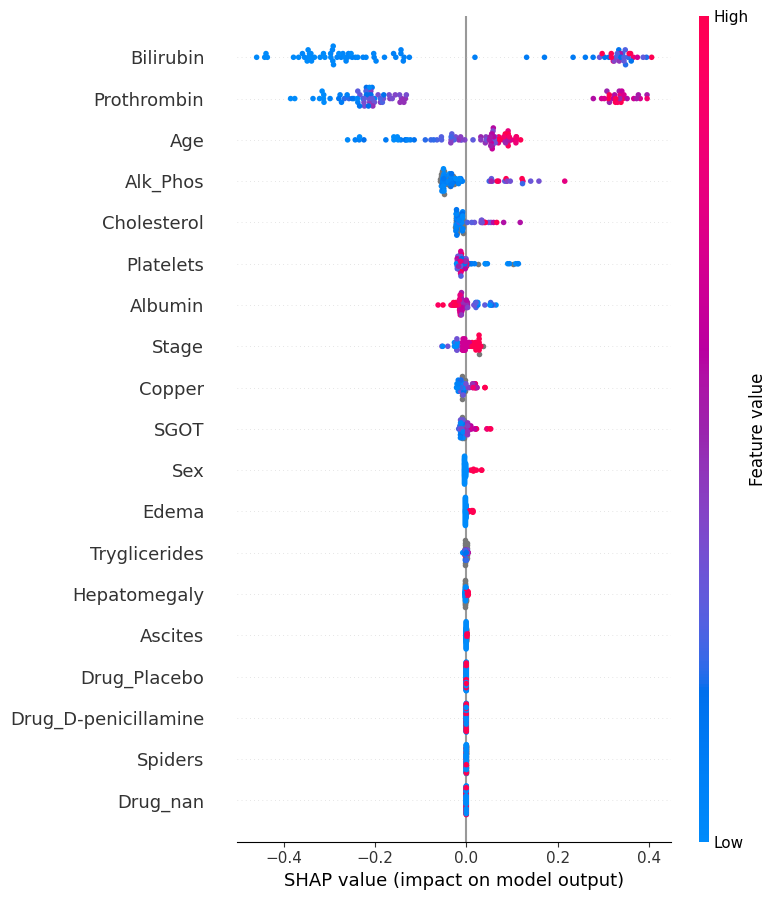

In [38]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_native)

shap.summary_plot(shap_values, X_test_native)

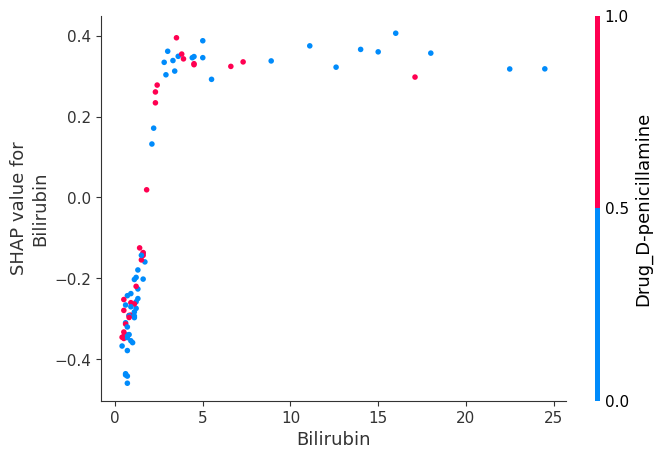

In [39]:
shap.dependence_plot('Bilirubin', shap_values, X_test_native)

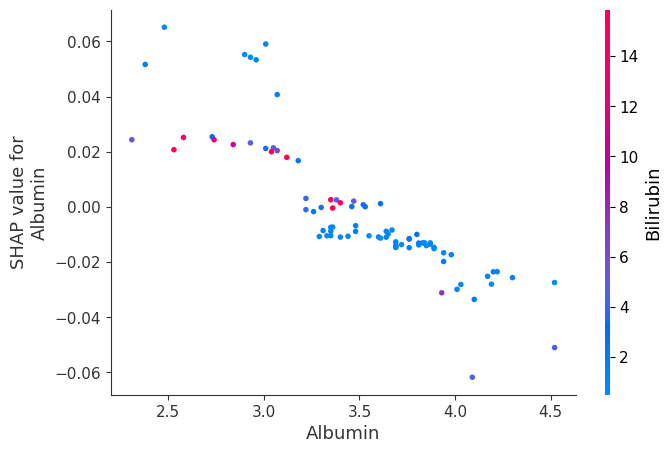

In [40]:
shap.dependence_plot('Albumin', shap_values, X_test_native)

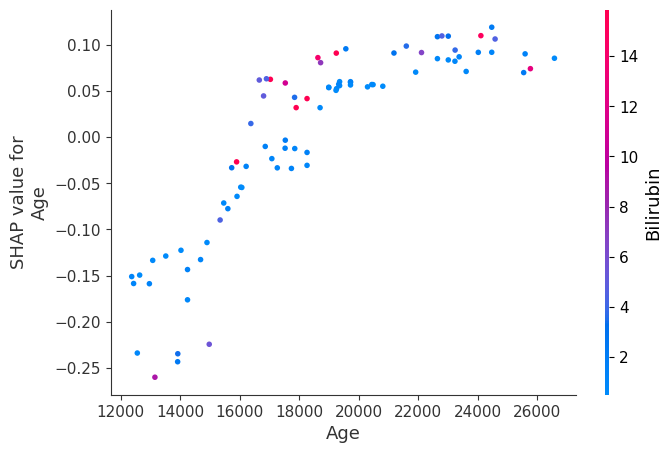

In [41]:
shap.dependence_plot('Age', shap_values, X_test_native)

In [42]:
# Convert Age dari hari ke tahun untuk interpretasi yang lebih mudah
X_test_native_display = X_test_native.copy()
X_test_native_display['Age_years'] = (X_test_native_display['Age'] / 365.25).round(1)
print(X_test_native_display[['Age', 'Age_years']].head())

       Age  Age_years
279  16858       46.2
219  23241       63.6
54   24020       65.8
211  17263       47.3
378  23011       63.0


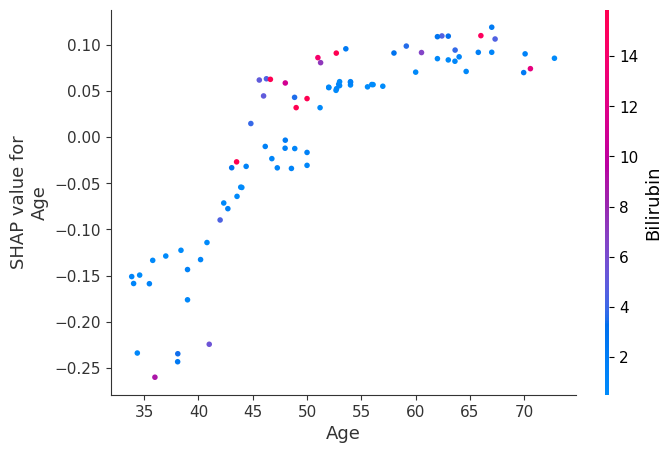

In [43]:
# Copy dataframe, replace NILAI Age jadi tahun (bukan bikin kolom baru)
X_test_display = X_test_native.copy()
X_test_display['Age'] = X_test_display['Age'] / 365.25

# Sekarang plot pakai nama kolom yang SAMA ('Age'), tapi nilainya sudah dalam tahun
shap.dependence_plot('Age', shap_values, X_test_display)

In [44]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_native.iloc[0])

In [45]:
death_indices = np.where(y_pred_best == 1)[0]
print(death_indices[:5])  # lihat beberapa index pasien yang diprediksi death

[1 2 4 5 7]


In [46]:
idx = death_indices[0]
shap.force_plot(explainer.expected_value, shap_values[idx], X_test_native.iloc[idx])

In [48]:
joblib.dump(best_xgb, 'xgb_cirrhosis_model.pkl')
print("Model saved!")

Model saved!
